In [19]:
import openmeteo_requests
import pandas as pd
import requests_cache

from retry_requests import retry

# ======================================================
# Open-Meteo Client
# ======================================================

cache_session = requests_cache.CachedSession(
    '.cache',
    expire_after=3600
)

retry_session = retry(
    cache_session,
    retries=5,
    backoff_factor=0.2
)

openmeteo = openmeteo_requests.Client(
    session=retry_session
)

# ======================================================
# Weather Cache
# ======================================================

weather_cache = {}

# ======================================================
# Fetch Function
# ======================================================

def fetch_weather(lat, lon, pass_time):

    date_str = pass_time.strftime("%Y-%m-%d")

    cache_key = (
        round(lat, 3),
        round(lon, 3),
        date_str
    )

    # 이미 조회한 경우
    if cache_key in weather_cache:
        return weather_cache[cache_key]

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date_str,
        "end_date": date_str,
        "hourly": [
            "cloud_cover",
            "precipitation",
            "visibility"
        ],
        "timezone": "Asia/Taipei"
    }

    responses = openmeteo.weather_api(url, params=params)

    response = responses[0]

    hourly = response.Hourly()

    weather_data = {
        "cloud_cover":
            hourly.Variables(0).ValuesAsNumpy(),

        "precipitation":
            hourly.Variables(1).ValuesAsNumpy(),

        "visibility":
            hourly.Variables(2).ValuesAsNumpy()
    }

    weather_cache[cache_key] = weather_data

    return weather_data

In [ ]:
for idx, row in df.iterrows():

    lat = row["latitude"]
    lon = row["longitude"]
    pass_time = row["pass_time"]

    weather = fetch_weather(
        lat,
        lon,
        pass_time
    )

    hour_idx = pass_time.hour

    cloud = weather["cloud_cover"][hour_idx]
    rain = weather["precipitation"][hour_idx]

    sensor = recommend_sensor(cloud, rain)

    print(sensor)

In [23]:
import openmeteo_requests
import requests_cache
import pandas as pd

from retry_requests import retry

# ======================================================
# Session
# ======================================================

cache_session = requests_cache.CachedSession(
    '.cache',
    expire_after=3600
)

retry_session = retry(
    cache_session,
    retries=5,
    backoff_factor=0.2
)

openmeteo = openmeteo_requests.Client(
    session=retry_session
)

# ======================================================
# API Request
# ======================================================

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 25.03,
    "longitude": 121.56,
    "start_date": "2022-08-04",
    "end_date": "2022-08-04",
    "hourly": [
        "cloud_cover",
        "precipitation",
        "visibility"
    ],
    "timezone": "Asia/Taipei"
}

responses = openmeteo.weather_api(url, params=params)

response = responses[0]

# ======================================================
# Hourly Data
# ======================================================

hourly = response.Hourly()

cloud_cover = hourly.Variables(0).ValuesAsNumpy()
precipitation = hourly.Variables(1).ValuesAsNumpy()
visibility = hourly.Variables(2).ValuesAsNumpy()

# ======================================================
# Time 생성
# ======================================================

time_index = pd.date_range(
    start=pd.to_datetime(hourly.Time(), unit="s"),
    end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
    freq=pd.Timedelta(seconds=hourly.Interval()),
    inclusive="left"
)

# ======================================================
# DataFrame
# ======================================================

df_weather = pd.DataFrame({
    "time": time_index,
    "cloud_cover": cloud_cover,
    "precipitation": precipitation,
    "visibility": visibility
})

print(df_weather.head())

                 time  cloud_cover  precipitation  visibility
0 2022-08-03 16:00:00          4.0            0.0         NaN
1 2022-08-03 17:00:00         25.0            0.0         NaN
2 2022-08-03 18:00:00         20.0            0.0         NaN
3 2022-08-03 19:00:00         20.0            0.0         NaN
4 2022-08-03 20:00:00         25.0            0.0         NaN


In [25]:
pass_time = pd.Timestamp("2022-08-04 10:23:00")

nearest_hour = pass_time.floor("h")

selected = df_weather[
    df_weather["time"] == nearest_hour
]

print(selected)

                  time  cloud_cover  precipitation  visibility
18 2022-08-04 10:00:00         43.0            0.1         NaN


## NASA Worldview 로 확인한 결과
- https://worldview.earthdata.nasa.gov/

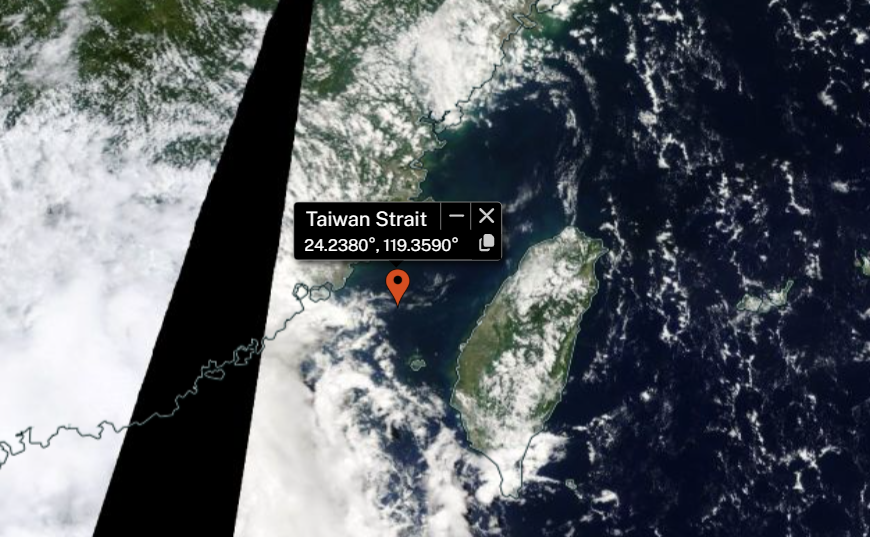